In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import zipfile

# Path to the zip file
zip_file_path = '/content/titanic.zip'

# Directory to extract to (current directory)
extraction_path = './'

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted to '{extraction_path}'")

'/content/titanic.zip' extracted to './'


After extraction, the `train.csv` and `test.csv` files should now be available in the current directory.

In [22]:
df = pd.read_csv("/content/train.csv")

In [30]:
print(df.shape)
print(df.isnull().sum())

(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [25]:
print(df.dtypes)


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [26]:
print(df.duplicated().sum())


0


In [11]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [31]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'], inplace=True)
df.drop_duplicates(inplace=True)
print("Nulls after cleaning:\n", df.isnull().sum())

Nulls after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [32]:
df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nShape:", df.shape)

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    1  22.0      1      0   7.2500           0           1
1         1       1    0  38.0      1      0  71.2833           0           0
2         1       3    0  26.0      0      0   7.9250           0           1
3         1       1    0  35.0      1      0  53.1000           0           1
4         0       3    1  35.0      0      0   8.0500           0           1

Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

Shape: (891, 9)


In [33]:
from sklearn.preprocessing import StandardScaler

# Define which columns to scale
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
# These are continuous numerical columns
# Pclass, Sex, Embarked are already 0/1 → no need to scale
# Survived is our TARGET column → never scale target

scaler = StandardScaler()
# StandardScaler → converts values to mean=0 and std=1
# Formula → (value - mean) / standard_deviation

df[num_cols] = scaler.fit_transform(df[num_cols])
# fit_transform() → learns mean & std from data, then scales it

print(df.head())
print("\nMean after scaling:\n", df[num_cols].mean().round(2))
print("\nStd after scaling:\n", df[num_cols].std().round(2))

   Survived  Pclass  Sex       Age     SibSp     Parch      Fare  Embarked_Q  \
0         0       3    1 -0.565736  0.432793 -0.473674 -0.502445           0   
1         1       1    0  0.663861  0.432793 -0.473674  0.786845           0   
2         1       3    0 -0.258337 -0.474545 -0.473674 -0.488854           0   
3         1       1    0  0.433312  0.432793 -0.473674  0.420730           0   
4         0       3    1  0.433312 -0.474545 -0.473674 -0.486337           0   

   Embarked_S  
0           1  
1           0  
2           1  
3           1  
4           1  

Mean after scaling:
 Age      0.0
Fare     0.0
SibSp    0.0
Parch    0.0
dtype: float64

Std after scaling:
 Age      1.0
Fare     1.0
SibSp    1.0
Parch    1.0
dtype: float64


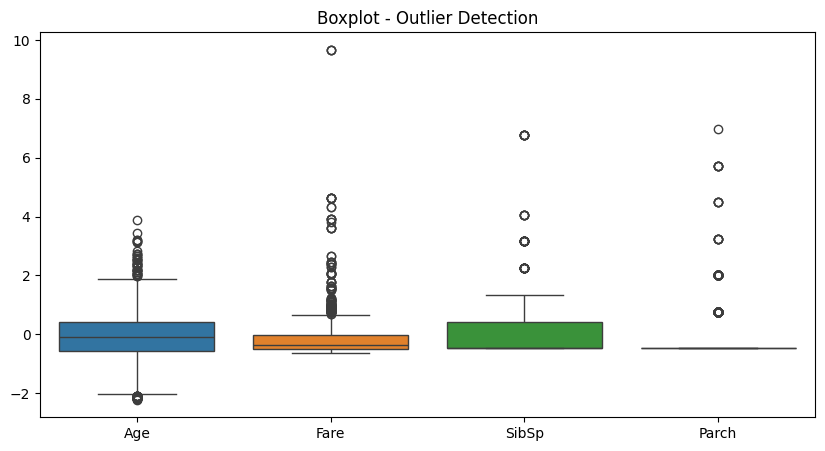

In [34]:
plt.figure(figsize=(10, 5))
# creates a figure of size 10 wide, 5 tall

sns.boxplot(data=df[['Age', 'Fare', 'SibSp', 'Parch']])
# boxplot → shows distribution of each column
# helps visually spot outliers (dots outside the box)

plt.title("Boxplot - Outlier Detection")
# adds title to the plot

plt.show()
# displays the plot

Shape before: (891, 9)
Shape after: (577, 9)


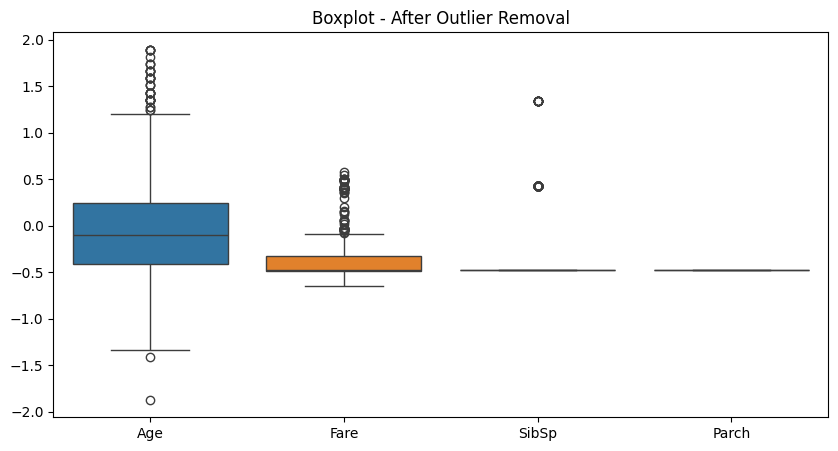

In [35]:
# IQR = Interquartile Range = Q3 - Q1
# Anything below Q1-1.5*IQR or above Q3+1.5*IQR = outlier

def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    # Q1 → value below which 25% of data falls

    Q3 = df[col].quantile(0.75)
    # Q3 → value below which 75% of data falls

    IQR = Q3 - Q1
    # IQR → middle 50% range of data

    lower = Q1 - 1.5 * IQR
    # lower bound → anything below this is outlier

    upper = Q3 + 1.5 * IQR
    # upper bound → anything above this is outlier

    return df[(df[col] >= lower) & (df[col] <= upper)]
    # keep only rows within the valid range

# Apply to columns that had severe outliers
print("Shape before:", df.shape)

for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    df = remove_outliers(df, col)
    # loop applies outlier removal one column at a time

print("Shape after:", df.shape)

# Plot again to confirm outliers removed
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Age', 'Fare', 'SibSp', 'Parch']])
plt.title("Boxplot - After Outlier Removal")
plt.show()

In [36]:
print("✅ Task 1 Complete!")
print("\nFinal Shape:", df.shape)
print("\nFinal Columns:", df.columns.tolist())
print("\nFinal Data Sample:")
print(df.head())

✅ Task 1 Complete!

Final Shape: (577, 9)

Final Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

Final Data Sample:
   Survived  Pclass  Sex       Age     SibSp     Parch      Fare  Embarked_Q  \
0         0       3    1 -0.565736  0.432793 -0.473674 -0.502445           0   
2         1       3    0 -0.258337 -0.474545 -0.473674 -0.488854           0   
3         1       1    0  0.433312  0.432793 -0.473674  0.420730           0   
4         0       3    1  0.433312 -0.474545 -0.473674 -0.486337           0   
5         0       3    1 -0.104637 -0.474545 -0.473674 -0.478116           1   

   Embarked_S  
0           1  
2           1  
3           1  
4           1  
5           0  
